# Predicción de Precios de Vivienda en México
**Autor:** Cesar Omar Miguel Gonzalez
**Proyecto:** Sistema Recomendador de Vivienda (Fases 1 a 5)

Este notebook contiene el pipeline de experimentación, desde el Análisis Exploratorio de Datos (EDA) hasta la Optimización de Hiperparámetros del modelo ganador (Random Forest), justificando cada decisión metodológica.

In [16]:
# Importaciones Globales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
from scipy.stats import skew

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Configuración Visual y de Entorno
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.1)

# Configuración de Rutas (Asumiendo que el Notebook está en la raíz del proyecto)
PATH_DATOS = "../data/processed/oferta_nacional_geo_final.csv"
PATH_SEDATU_FIN = "../data/raw/sedatu/getfinanciamiento_nacional_20260405.csv"
PATH_SEDATU_REG = "../data/raw/sedatu/getregistro_nacional_20260405.csv"
PATH_RESULTADOS = "../data/resultados_modelos.csv"

print("Entorno configurado y librerías cargadas exitosamente.")

Entorno configurado y librerías cargadas exitosamente.


## 1. Análisis Exploratorio de Datos (EDA)
Evaluación de asimetría, detección de valores atípicos (outliers) mediante el rango intercuartílico, y análisis de correlación lineal entre atributos estructurales.

Iniciando exploración de datos...
Skewness - Precio: 4.61 | Superficie: 453.65


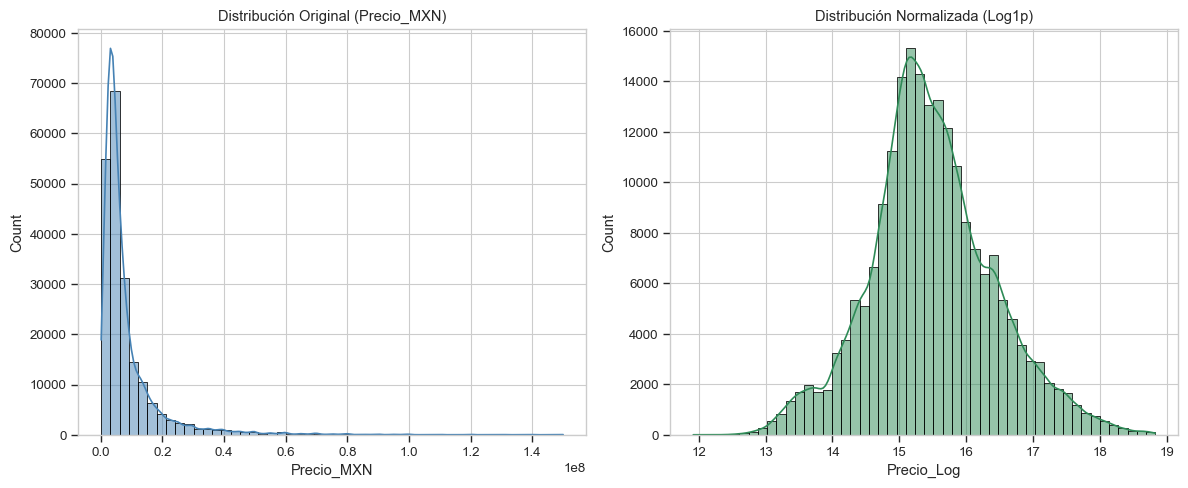


Límite IQR Precio: $18,125,000.00 | Outliers: 20063 (9.74%)


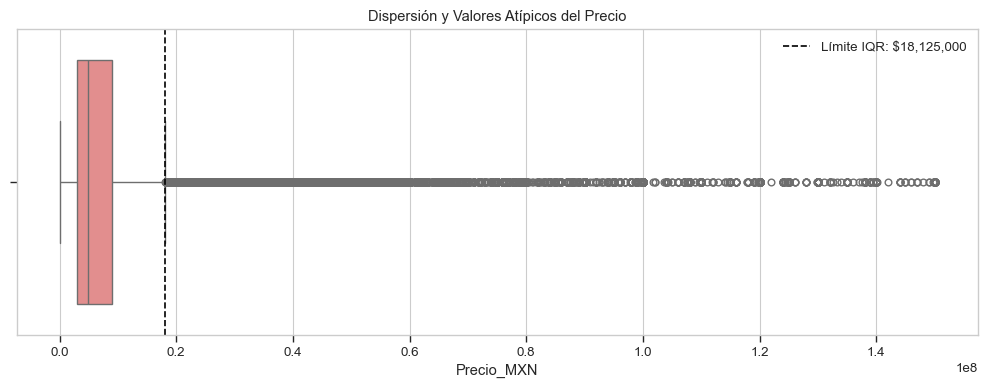

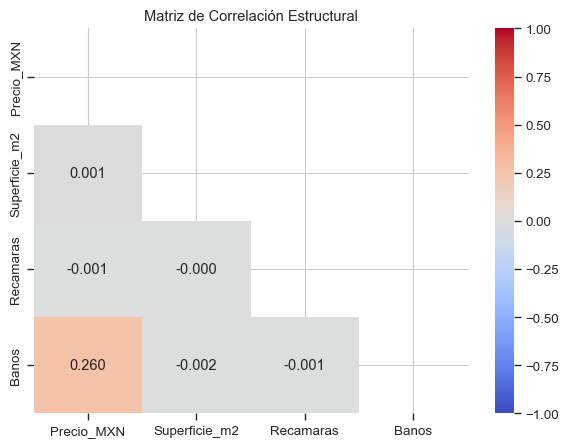


Generando mapa de plusvalía (Muestra aleatoria para optimizar rendimiento del notebook)...


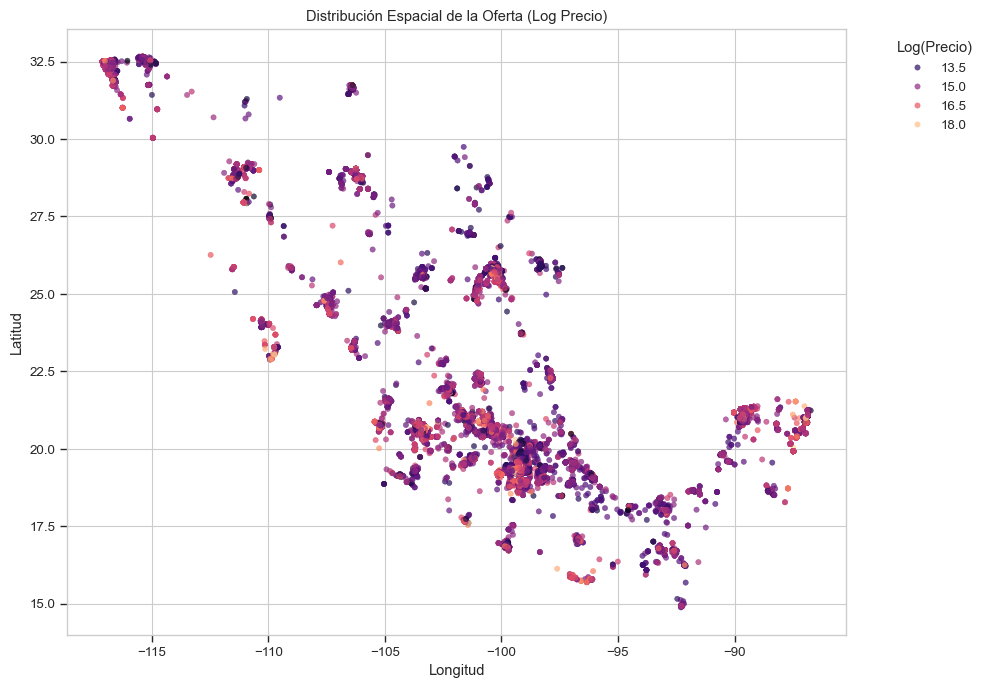

In [17]:
print("Iniciando exploración de datos...")
df = pd.read_csv(PATH_DATOS)

# Incluimos coordenadas para poder generar el mapa al final
cols_analisis = ['Precio_MXN', 'Superficie_m2', 'Recamaras', 'Banos', 'Latitud', 'Longitud']
df_analisis = df.dropna(subset=cols_analisis).copy()

# ==========================================
# 1. SKEWNESS Y DISTRIBUCIÓN DE PRECIO
# ==========================================
asimetria_precio = skew(df_analisis['Precio_MXN'])
asimetria_superficie = skew(df_analisis['Superficie_m2'])
print(f"Skewness - Precio: {asimetria_precio:.2f} | Superficie: {asimetria_superficie:.2f}")

# Transformación logarítmica para visualización
df_analisis['Precio_Log'] = np.log1p(df_analisis['Precio_MXN'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_analisis['Precio_MXN'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución Original (Precio_MXN)')

sns.histplot(df_analisis['Precio_Log'], bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribución Normalizada (Log1p)')
plt.tight_layout()
plt.show()

# ==========================================
# 2. OUTLIERS (REGLA IQR Y BOXPLOT)
# ==========================================
Q1 = df_analisis['Precio_MXN'].quantile(0.25)
Q3 = df_analisis['Precio_MXN'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_analisis[df_analisis['Precio_MXN'] > limite_superior]
pct_outliers = (len(outliers) / len(df_analisis)) * 100
print(f"\nLímite IQR Precio: ${limite_superior:,.2f} | Outliers: {len(outliers)} ({pct_outliers:.2f}%)")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_analisis['Precio_MXN'], color='lightcoral')
plt.axvline(limite_superior, color='black', linestyle='--', label=f'Límite IQR: ${limite_superior:,.0f}')
plt.title('Dispersión y Valores Atípicos del Precio')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 3. MATRIZ DE CORRELACIÓN
# ==========================================
cols_numericas = ['Precio_MXN', 'Superficie_m2', 'Recamaras', 'Banos']
matriz_corr = df_analisis[cols_numericas].corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación Estructural')
plt.show()

# ==========================================
# 4. MAPA GEOESPACIAL DE PLUSVALÍA
# ==========================================
print("\nGenerando mapa de plusvalía (Muestra aleatoria para optimizar rendimiento del notebook)...")
# Usamos una muestra de 50,000 puntos para que el Jupyter Notebook no se congele al renderizar
df_muestra_mapa = df_analisis.sample(n=min(50000, len(df_analisis)), random_state=42)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_muestra_mapa['Longitud'], 
    y=df_muestra_mapa['Latitud'], 
    hue=df_muestra_mapa['Precio_Log'], 
    palette='magma', 
    s=15, 
    alpha=0.7,
    edgecolor=None
)
plt.title('Distribución Espacial de la Oferta (Log Precio)')
plt.legend(title='Log(Precio)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 2. Análisis de Umbrales Oficiales (SEDATU)
Se analizan los montos reales de financiamiento a nivel nacional para establecer empíricamente los límites de discretización para los segmentos: Económico, Medio y Lujo.

In [18]:
print("Procesando datos históricos de Financiamiento SEDATU...")
try:
    df_fin = pd.read_csv(PATH_SEDATU_FIN, encoding='utf-8')
    df_valid = df_fin[(df_fin['acciones'] > 0) & (df_fin['monto'] > 0)]
    
    resumen_anual = df_valid.groupby('ano').agg(
        total_acciones=('acciones', 'sum'),
        total_monto=('monto', 'sum')
    ).reset_index()
    
    resumen_anual['monto_promedio'] = resumen_anual['total_monto'] / resumen_anual['total_acciones']
    resumen_anual['Monto Promedio'] = resumen_anual['monto_promedio'].apply(lambda x: f"${x:,.2f} MXN")
    resumen_anual['Total Acciones'] = resumen_anual['total_acciones'].apply(lambda x: f"{x:,.0f}")
    
    print("\nCosto Promedio de la Vivienda Financiada por Año:")
    print(resumen_anual[['ano', 'Total Acciones', 'Monto Promedio']].to_string(index=False))
    
except FileNotFoundError:
    print(f"⚠️ Archivo no encontrado en: {PATH_SEDATU_FIN}")
except Exception as e:
    print(f"Error procesando el archivo: {e}")

Procesando datos históricos de Financiamiento SEDATU...

Costo Promedio de la Vivienda Financiada por Año:
 ano Total Acciones  Monto Promedio
2015      1,308,836 $245,636.65 MXN
2016      1,077,511 $317,667.70 MXN
2017      1,010,535 $289,801.32 MXN
2018      1,102,193 $330,680.89 MXN
2019        942,483 $407,503.34 MXN
2020        847,067 $474,242.08 MXN
2021      1,059,241 $466,547.85 MXN
2022        772,537 $653,246.27 MXN
2023        720,550 $714,286.22 MXN
2024        830,931 $687,981.96 MXN
2025        358,316 $996,345.72 MXN


## 3. Comparativa de Algoritmos de Escalamiento
Dado el sesgo extremo ($g_1 = 453.65$) en la superficie, se evalúa el impacto matemático de aplicar Min-Max, Z-Score y Robust Scaling.

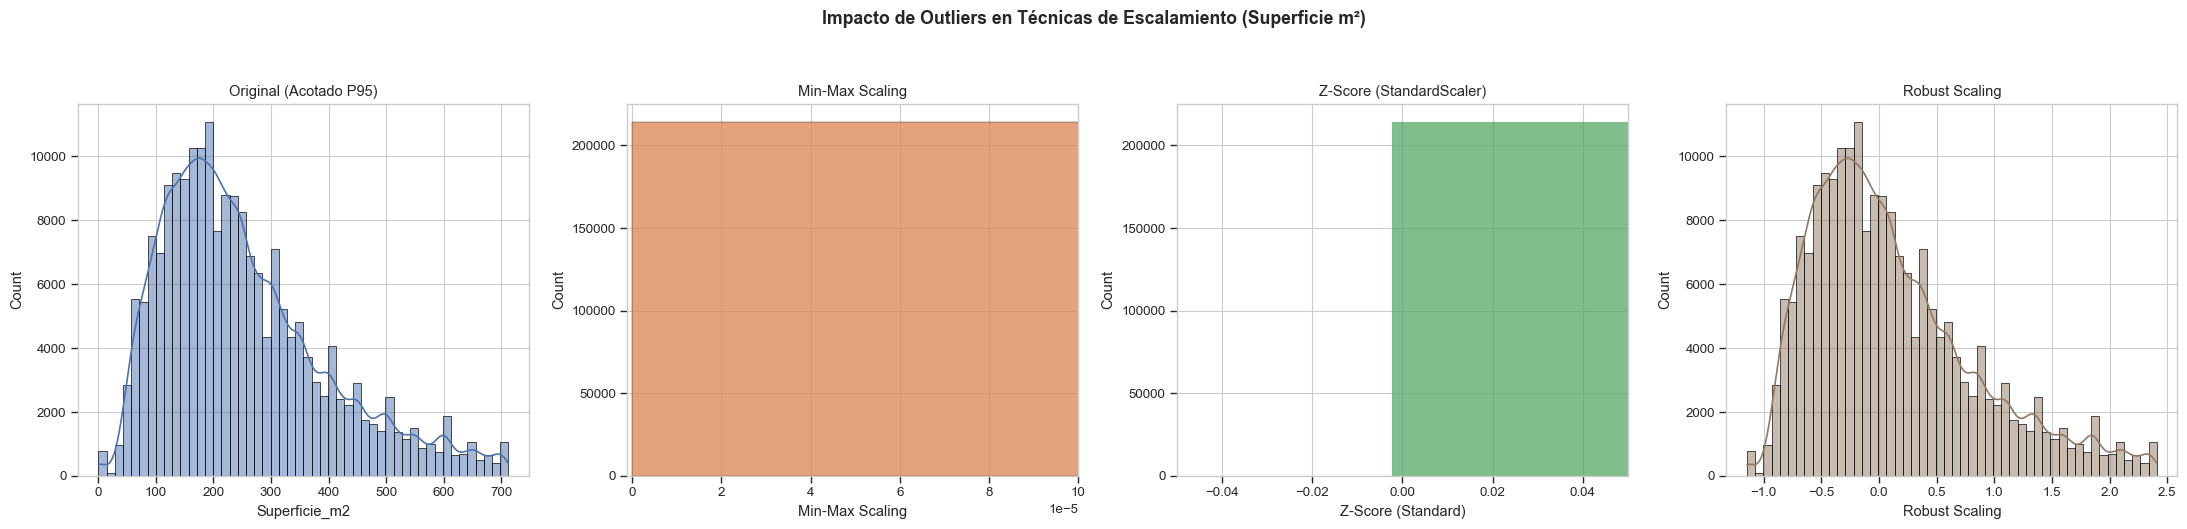

In [19]:
df_clean = df.dropna(subset=['Superficie_m2']).copy()
X_sup = df_clean[['Superficie_m2']]

scalers = {
    'Original': None,
    'Min-Max Scaling': MinMaxScaler(),
    'Z-Score (Standard)': StandardScaler(),
    'Robust Scaling': RobustScaler()
}

resultados = {'Original': X_sup['Superficie_m2'].values}
for nombre, scaler in scalers.items():
    if scaler is not None:
        resultados[nombre] = scaler.fit_transform(X_sup).flatten()

df_resultados = pd.DataFrame(resultados)

# Visualización del impacto acotado al percentil 95
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Impacto de Outliers en Técnicas de Escalamiento (Superficie m²)', fontweight='bold', y=1.05)

limite_superior_normal = X_sup['Superficie_m2'].quantile(0.95)

# Original
sns.histplot(data=df_clean[df_clean['Superficie_m2'] < limite_superior_normal], x='Superficie_m2', bins=50, ax=axes[0], color='#4C72B0', kde=True)
axes[0].set_title('Original (Acotado P95)')

# Min-Max
sns.histplot(data=df_resultados, x='Min-Max Scaling', bins=100, ax=axes[1], color='#DD8452', kde=False)
axes[1].set_xlim(-0.000001, 0.0001)
axes[1].set_title('Min-Max Scaling')

# Z-Score
sns.histplot(data=df_resultados, x='Z-Score (Standard)', bins=1000, ax=axes[2], color='#55A868', kde=False)
axes[2].set_xlim(-0.05, 0.05)
axes[2].set_title('Z-Score (StandardScaler)')

# Robust Scaling
sns.histplot(data=df_resultados[df_resultados['Original'] < limite_superior_normal], x='Robust Scaling', bins=50, ax=axes[3], color='#937860', kde=True)
axes[3].set_title('Robust Scaling')

plt.tight_layout()
plt.show()

## 4. Experimento de Manejo de Desbalanceo
Segmentación del mercado inmobiliario y evaluación de técnicas de remuestreo (SMOTE vs Undersampling) usando regresión logística como estimador base.

In [20]:
bins = [0, 2000000, 6000000, float('inf')]
labels = [0, 1, 2] # 0: Económico, 1: Medio, 2: Lujo
df_clean = df.dropna(subset=['Superficie_m2', 'Precio_MXN', 'Recamaras', 'Banos']).copy()
df_clean['Segmento_Mercado'] = pd.cut(df_clean['Precio_MXN'], bins=bins, labels=labels)

X = df_clean[['Superficie_m2', 'Recamaras', 'Banos']]
y = df_clean['Segmento_Mercado']

X_sample, _, y_sample, _ = train_test_split(X, y, train_size=30000, stratify=y, random_state=42)

dist = y_sample.value_counts(normalize=True) * 100
print("Distribución de clases (Muestra 30k):")
print(f"Clase 0 (Económico): {dist[0]:.2f}% (Minoritaria)")
print(f"Clase 1 (Medio): {dist[1]:.2f}%")
print(f"Clase 2 (Lujo): {dist[2]:.2f}%\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovo']
clf_base = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

pipelines = {
    "Baseline": Pipeline([('scaler', RobustScaler()), ('clf', clf_base)]),
    "Undersampling": Pipeline([('scaler', RobustScaler()), ('sampler', RandomUnderSampler(random_state=42)), ('clf', clf_base)]),
    "SMOTE": Pipeline([('scaler', RobustScaler()), ('sampler', SMOTE(random_state=42)), ('clf', clf_base)])
}

for nombre, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X_sample, y_sample, scoring=metricas, cv=cv, n_jobs=-1)
    print(f"{nombre:<15} | F1-Score: {np.mean(scores['test_f1_macro']):.4f} | Recall: {np.mean(scores['test_recall_macro']):.4f} | ROC-AUC: {np.mean(scores['test_roc_auc_ovo']):.4f}")

Distribución de clases (Muestra 30k):
Clase 0 (Económico): 13.21% (Minoritaria)
Clase 1 (Medio): 46.36%
Clase 2 (Lujo): 40.44%

Baseline        | F1-Score: 0.7356 | Recall: 0.7219 | ROC-AUC: 0.8806
Undersampling   | F1-Score: 0.6888 | Recall: 0.7246 | ROC-AUC: 0.8766
SMOTE           | F1-Score: 0.7179 | Recall: 0.7326 | ROC-AUC: 0.8813


## 5. Benchmark de Algoritmos Supervisados
Evaluación del desempeño de múltiples clasificadores aplicando RobustScaler y SMOTE dentro de un pipeline de validación cruzada.

In [21]:
X_bench = df_clean[['Superficie_m2', 'Recamaras', 'Banos', 'Latitud', 'Longitud']].dropna()
y_bench = df_clean.loc[X_bench.index, 'Segmento_Mercado']

X_train_bench, _, y_train_bench, _ = train_test_split(X_bench, y_bench, train_size=50000, stratify=y_bench, random_state=42)

modelos = {
    "Regresion Logistica": LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Arbol de Decision": DecisionTreeClassifier(max_depth=15, random_state=42),
    "SVM (Kernel RBF)": SVC(kernel='rbf', max_iter=2000, probability=True, random_state=42),
    "Red Neuronal (MLP)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
}

resultados_lista = []
print("Entrenando modelos...")
for nombre, clasificador in modelos.items():
    inicio = time.time()
    pipe = Pipeline([('scaler', RobustScaler()), ('smote', SMOTE(random_state=42)), ('clf', clasificador)])
    
    try:
        scores = cross_validate(pipe, X_train_bench, y_train_bench, scoring=metricas, cv=cv, n_jobs=-1)
        res = {
            'Modelo': nombre,
            'F1-Score': np.mean(scores['test_f1_macro']),
            'ROC-AUC': np.mean(scores['test_roc_auc_ovo']),
            'Tiempo (s)': round(time.time() - inicio, 2)
        }
        resultados_lista.append(res)
        print(f"  -> {nombre} listo en {res['Tiempo (s)']}s.")
    except Exception as e:
        print(f"  -> Error en {nombre}: {e}")

df_resultados_bench = pd.DataFrame(resultados_lista).sort_values(by='F1-Score', ascending=False)
display(df_resultados_bench)

Entrenando modelos...
  -> Regresion Logistica listo en 2.13s.
  -> KNN (k=5) listo en 0.62s.
  -> Arbol de Decision listo en 0.44s.
  -> SVM (Kernel RBF) listo en 95.83s.
  -> Red Neuronal (MLP) listo en 21.16s.
  -> Random Forest listo en 2.74s.


,Modelo,F1-Score,ROC-AUC,Tiempo (s)
5,Random Forest,0.810381,0.945054,2.74
2,Arbol de Decision,0.775093,0.872846,0.44
1,KNN (k=5),0.768000,0.908878,0.62
4,Red Neuronal (MLP),0.765495,0.926505,21.16
0,Regresion Logistica,0.612477,0.848405,2.13
3,SVM (Kernel RBF),0.421885,0.704745,95.83
